In [ ]:
from transformers import CanineModel, CanineTokenizer
from classes.style_encoder import StyleEncoder
from classes.conversational_dataset import ConversationDataset
from torch.utils.data import DataLoader
from torch.nn.functional import normalize
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import emoji
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import string

device = "cuda" if torch.cuda.is_available() else "cpu"

Skipping import of cpp extensions due to incompatible torch version 2.7.1+cu118 for torchao version 0.15.0             Please see https://github.com/pytorch/ao/issues/2919 for more info
W1226 09:29:12.572000 25608 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [2]:
save_dir = "../models/style_retriever"

tokenizer = CanineTokenizer.from_pretrained(save_dir)

encoder = CanineModel.from_pretrained(save_dir)

model = StyleEncoder()
model.encoder = encoder
model.proj.load_state_dict(torch.load(f"{save_dir}/projection_head.pt"))
model.eval()
model.to("cuda")

StyleEncoder(
  (encoder): CanineModel(
    (char_embeddings): CanineEmbeddings(
      (HashBucketCodepointEmbedder_0): Embedding(16384, 96)
      (HashBucketCodepointEmbedder_1): Embedding(16384, 96)
      (HashBucketCodepointEmbedder_2): Embedding(16384, 96)
      (HashBucketCodepointEmbedder_3): Embedding(16384, 96)
      (HashBucketCodepointEmbedder_4): Embedding(16384, 96)
      (HashBucketCodepointEmbedder_5): Embedding(16384, 96)
      (HashBucketCodepointEmbedder_6): Embedding(16384, 96)
      (HashBucketCodepointEmbedder_7): Embedding(16384, 96)
      (char_position_embeddings): Embedding(16384, 768)
      (token_type_embeddings): Embedding(16, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (initial_char_encoder): CanineEncoder(
      (layer): ModuleList(
        (0): CanineLayer(
          (attention): CanineAttention(
            (self): CanineSelfAttention(
              (query): Linear(

In [3]:
rows = pd.read_csv("../data/processed/retriever_val_undersampled.csv").to_dict(orient="records")
val_dataset = ConversationDataset(rows, tokenizer, max_length=512)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4
)

In [4]:
# =============================
# SANITY CHECK: Embedding Norms
# =============================
# Purpose: Ensure embeddings are not collapsed and L2 normalization works.
# - mean/std check tells you if embeddings vary
# - norm check ensures embeddings are unit vectors

model.eval()
all_embeddings = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        z = model(input_ids, attention_mask)
        all_embeddings.append(z.cpu())

embeddings = torch.cat(all_embeddings)
print("Embedding mean:", embeddings.mean().item())
print("Embedding std:", embeddings.std().item())
print("Embedding L2 norm mean:", embeddings.norm(dim=1).mean().item())


Embedding mean: 0.009556741453707218
Embedding std: 0.0878702700138092
Embedding L2 norm mean: 1.0


In [5]:
# =============================
# TOP-K RETRIEVAL (BY AUTHOR)
# =============================
# Purpose: Check if embeddings cluster messages from the same author.
# Method:
# 1. Compute cosine similarity between all embeddings
# 2. For each message, check if top-k nearest neighbors include the same author
# 3. Compute proportion (accuracy)

# Normalize embeddings to ensure cosine similarity works
embeddings = normalize(embeddings, dim=1)

all_authors = [batch["author"] for batch in val_loader.dataset]
all_authors = [a for sublist in all_authors for a in (sublist if isinstance(sublist, list) else [sublist])]

def topk_accuracy(embeddings, authors, k=5):
    sims = embeddings @ embeddings.T
    sims.fill_diagonal_(-1)  # ignore self-similarity
    topk_indices = sims.topk(k, dim=1).indices
    correct = 0
    for i, idxs in enumerate(topk_indices):
        topk_authors = [authors[j] for j in idxs]
        if authors[i] in topk_authors:
            correct += 1
    return correct / len(authors)

acc5 = topk_accuracy(embeddings, all_authors, k=5)
print("Top-5 retrieval accuracy by author:", acc5)

Top-5 retrieval accuracy by author: 0.95825


In [6]:
# =============================
# STYLE FEATURE CORRELATION
# =============================
# Purpose: Check if embeddings encode specific stylistic features
# Features: emoji count, uppercase ratio, punctuation ratio

# Correct key: "content"
all_contents = [item["content"] for item in val_loader.dataset]

def extract_style_features(texts):
    emoji_counts = [sum(1 for c in t if emoji.is_emoji(c)) for t in texts]
    uppercase_ratio = [sum(1 for c in t if c.isupper()) / max(len(t), 1) for t in texts]
    punct_ratio = [sum(1 for c in t if c in "!?.") / max(len(t), 1) for t in texts]
    return np.array(emoji_counts), np.array(uppercase_ratio), np.array(punct_ratio)

emoji_counts, uppercase_ratio, punct_ratio = extract_style_features(all_contents)

def embedding_style_corr(embeddings, feature_array):
    sim = cosine_similarity(embeddings)
    style_diff = np.abs(feature_array[:, None] - feature_array[None, :])
    corr = np.corrcoef(sim.flatten(), -style_diff.flatten())[0, 1]
    return corr

print("Emoji correlation:", embedding_style_corr(embeddings, emoji_counts))
print("Caps correlation:", embedding_style_corr(embeddings, uppercase_ratio))
print("Punctuation correlation:", embedding_style_corr(embeddings, punct_ratio))


Emoji correlation: 0.002352675978601185
Caps correlation: 0.15216070697306378
Punctuation correlation: 0.11397402266245756


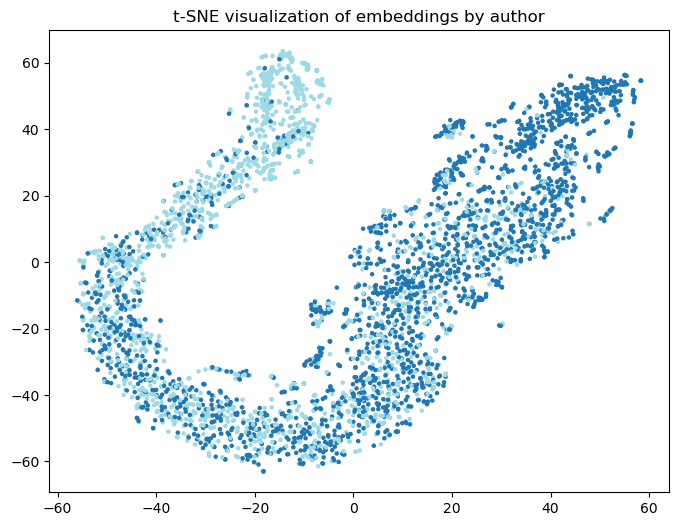

In [7]:
# =============================
# CLUSTER VISUALIZATION (t-SNE)
# =============================
# Purpose: Visual check if messages with the same author or style form clusters
# Method: Reduce embeddings to 2D using t-SNE and plot

tsne = TSNE(n_components=2, random_state=42)
z2d = tsne.fit_transform(embeddings.numpy())

# Map authors to colors
author_ids = [hash(a)%100 for a in all_authors]

plt.figure(figsize=(8,6))
plt.scatter(z2d[:,0], z2d[:,1], c=author_ids, cmap="tab20", s=5)
plt.title("t-SNE visualization of embeddings by author")
plt.show()


In [ ]:
# =============================
# ABLATION TEST: Emoji removal
# =============================
# Purpose: Check if embeddings encode emojis
# Method: Remove emojis from content and compare embedding shift

# --------------------------------------------------
# Assumptions:
# - model is already loaded and trained
# - tokenizer is already loaded
# - val_loader is built from ConversationDataset
# - ConversationDataset returns:
#   input_ids, attention_mask, author, content
# --------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# --------------------------------------------------
# Style ablation helpers
# --------------------------------------------------

def remove_emojis(text: str) -> str:
    return emoji.replace_emoji(text, replace="")

def remove_punctuation(text: str) -> str:
    return text.translate(str.maketrans("", "", string.punctuation))

def lowercase(text: str) -> str:
    return text.lower()

# --------------------------------------------------
# Safe batched embedding function (CANINE-safe)
# --------------------------------------------------

def embed_texts_batched(
    texts,
    model,
    tokenizer,
    device,
    batch_size=8,
    max_length=512
):
    embeddings = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]

        enc = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        with torch.no_grad():
            z = model(
                enc["input_ids"].to(device),
                enc["attention_mask"].to(device)
            )
            z = normalize(z, dim=1).cpu()

        embeddings.append(z)

        # Important for CANINE to avoid fragmentation
        del enc, z
        torch.cuda.empty_cache()

    return torch.cat(embeddings, dim=0)

# --------------------------------------------------
# Collect raw texts from ConversationDataset
# --------------------------------------------------

texts = [item["content"] for item in val_loader.dataset]

# --------------------------------------------------
# Compute original embeddings
# --------------------------------------------------

z_original = embed_texts_batched(
    texts=texts,
    model=model,
    tokenizer=tokenizer,
    device=device,
    batch_size=8
)

# --------------------------------------------------
# Emoji ablation
# --------------------------------------------------

texts_no_emoji = [remove_emojis(t) for t in texts]

z_no_emoji = embed_texts_batched(
    texts=texts_no_emoji,
    model=model,
    tokenizer=tokenizer,
    device=device,
    batch_size=8
)

# --------------------------------------------------
# Compute embedding shift
# --------------------------------------------------

cos_sim = torch.nn.functional.cosine_similarity(
    z_original,
    z_no_emoji,
    dim=1
)

shift = 1.0 - cos_sim

print("=== Emoji Ablation Results ===")
print(f"Mean embedding shift: {shift.mean().item():.4f}")
print(f"Std embedding shift : {shift.std().item():.4f}")
print(f"Min shift           : {shift.min().item():.4f}")
print(f"Max shift           : {shift.max().item():.4f}")


=== Emoji Ablation Results ===
Mean embedding shift: 0.0010
Std embedding shift : 0.0059
Min shift           : -0.0000
Max shift           : 0.1026
